In [1]:
print()

In [ ]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from helper_functions import accuracy_fn
from timeit import default_timer as timer
from tqdm.auto import tqdm

train_data = datasets.FashionMNIST(
    root= "data_1", #Where to download
    train= True, #Do we want the training dataset?
    download= True, #Do we want to download? Yes/No
    transform= torchvision.transforms.ToTensor(), #How we want to transform the data
    target_transform= None #How we want to transform the label/target
)

test_data = datasets.FashionMNIST(
    root= "data_1",
    train= False,
    download= True,
    transform= ToTensor(),
    target_transform= None
)

image, label = train_data[0]

photos_name = train_data.classes

#plt.imshow(image.squeeze())

torch.manual_seed(42)

#fig = plt.figure(figsize=(9, 9))
rows, colm = 4, 4
for i in range(1, rows * colm + 1):
  random_idx = torch.randint(0, len(train_data), size= [1]).item()
  image, label = train_data[random_idx]
  #fig.add_subplot(rows, colm, i)
  #plt.imshow(image.squeeze(), cmap= "gray")
  #plt.title(photos_name[label])
  #plt.axis(False)

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset= train_data,
    batch_size= BATCH_SIZE,
    shuffle= True
)

test_dataloader = DataLoader(
    dataset= test_data,
    batch_size= BATCH_SIZE,
    shuffle= False
)

train_feature_batch, train_label_batch = next(iter(train_dataloader))

torch.manual_seed(42)

random_idx = torch.randint(0, len(train_feature_batch), size=[1]).item()
img, label = train_feature_batch[random_idx], train_label_batch[random_idx]

#plt.imshow(img.squeeze(), cmap= "gray")
#plt.title(photos_name[label])
#plt.axis(False)

flatten_model = nn.Flatten()

x = train_feature_batch[0]

output = flatten_model(x)

class FashionModelMNISTV0(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int
               ):

    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features= hidden_units),
        nn.Linear(in_features= hidden_units, out_features= output_shape),
    )

  def forward(self, x):
    return self.layer_stack(x)

torch.manual_seed(42)

model_0 = FashionModelMNISTV0(input_shape= 784,
                              hidden_units= 10,
                              output_shape= len(photos_name)).to("cpu")


loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params= model_0.parameters(),
                            lr= 0.1)

def train_time(start: float,
               end: float,
               device: torch.device= None):

  total_time = end - start
  print(f"Device: {device} | Train time is {total_time}")
  return total_time

#start_timer = timer()
#end_timer = timer()
#train_time(start_timer, end_timer)

torch.manual_seed(42)

train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epochs: {epoch}\n------")
  #Training
  train_loss = 0

  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()

    y_pred = model_0(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      test_pred = model_0(X_test)

      test_loss += loss_fn(test_pred, y_test).item()

      test_acc += accuracy_fn(y_true= y_test,
                              y_pred= test_pred.argmax(dim= 1))

    #Test loss average per batch
    test_loss /= len(test_dataloader)
    #Test acc per average per batch
    test_acc /= len(test_dataloader)

  print(f"\nTrain loss: {train_loss:.2f} | Test loss: {test_loss:.2f} | Test acc: {test_acc:.2f}%")

train_time_end_on_cpu = timer()
total_train_time_on_model = train_time(start= train_time_start_on_cpu,
                                       end= train_time_end_on_cpu,
                                       device= next(model_0.parameters()).device)

import torch
from torch import nn
def eval_mode(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn):

  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      y = torch.tensor(y)
      y_pred = model(X)

      loss += loss_fn(y_pred, y)

      acc += accuracy_fn(y_true= y,
                         y_pred= y_pred.argmax(dim= 1))

    # Calculate the average loss and accuracy
    loss /= len(data_loader)
    acc /= len(data_loader)

  return{"model_name": model.__class__.__name__,
         "model_class": loss.item(),
         "model_acc": acc}

model_0_results = eval_mode(model= model_0, data_loader= test_dataloader,
                            loss_fn= loss_fn,
                            accuracy_fn= accuracy_fn)

torch.cuda.is_available()

from helper_functions import accuracy_fn, print_train_time
device = "cuda" if torch.cuda.is_available() else "cpu"

class FashionModelMNISTV1(nn.Module):
  def __init__(self, input_shape: int,
               output_shape: int,
               hidden_units: int):
    super().__init__()
    self.Layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features= hidden_units),
        nn.ReLU(),
        nn.Linear(in_features= hidden_units, out_features= output_shape),
        nn.ReLU()
    )

  def forward(self, x: torch.Tensor):
    return self.Layer_stack(x)

torch.manual_seed(42)
model_1 = FashionModelMNISTV1(input_shape= 784,
                              output_shape= len(photos_name),
                              hidden_units= 10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_1.parameters(),
                            lr= 0.1)

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device):

  train_loss, train_acc = 0, 0

  model.train()

  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true= y,
                               y_pred= y_pred.argmax(dim= 1)) #To go from logits to predictions labels

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}%| ")

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn,
              accuracy_fn,
              device):
  """To improve the model"""

  test_loss, test_acc = 0, 0

  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      test_pred = model(X)

      test_loss += loss_fn(test_pred, y).item()
      test_acc += accuracy_fn(y_true= y,
                              y_pred= test_pred.argmax(dim= 1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.2f} | Test Acc: {test_acc:.2f}%\n")

torch.manual_seed(42)

from timeit import default_timer as timer

start_timer_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----------")

  train_step(model_1, train_dataloader, loss_fn, optimizer, accuracy_fn, device)

  test_step(model_1, test_dataloader, loss_fn, accuracy_fn, device)

end_timer_on_gpu = timer()
total_train_time_on_model_1 = print_train_time(start= start_timer_on_gpu,
                                               end= end_timer_on_gpu,
                                               device= device)

model_1_results = eval_mode(model_1, test_dataloader, loss_fn, accuracy_fn)

#Our first CNN Model
#Yaaay(below us)
class FashionModelMNISTV2(nn.Module):
  def __init__(self, input_shape, output_shape, hidden_units):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(in_channels= input_shape, out_channels= hidden_units,
                kernel_size= 3,
                padding= 1,
                stride= 1),
      nn.ReLU(),
      nn.Conv2d(in_channels= hidden_units, out_channels= hidden_units,
                kernel_size= 3,
                padding= 1,
                stride= 1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
      nn.Conv2d(in_channels= hidden_units, out_channels= hidden_units,
                kernel_size= 3,
                padding= 1,
                stride= 1),

      nn.ReLU(),

      nn.Conv2d(in_channels= hidden_units, out_channels= hidden_units,
                kernel_size= 3,
                padding= 1,
                stride= 1),
      nn.ReLU(),

      nn.MaxPool2d(kernel_size= 2)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features= hidden_units * 7 * 7, out_features= output_shape)

    )

  def forward(self, x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    return x

torch.manual_seed(42)

model_2 = FashionModelMNISTV2(input_shape= 1, #input shape depends on the number of colors of image which is 3 but image we are working is one 
                              hidden_units= 10,
                               output_shape= len(photos_name)).to(device)



In [15]:
torch.manual_seed(42)
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

#Create a single conv layer

conv_layer = nn.Conv2d(in_channels= 3,
                       out_channels= 10,
                       kernel_size= 3,
                       padding= 0,
                       stride= 1)

conv_output = conv_layer(test_image.unsqueeze(0))


In [16]:
max_pool_layer = nn.MaxPool2d(kernel_size= 2)

test_image_through_conv = conv_layer(test_image.unsqueeze(0))

test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)

print(test_image_through_conv.shape)
print(test_image_through_conv_and_max_pool.shape)

torch.Size([1, 10, 62, 62])
torch.Size([1, 10, 31, 31])


In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_2.parameters(),
                            lr= 0.1)

torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer

train_time_start_model_2 = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(model_2, train_dataloader, loss_fn, optimizer, accuracy_fn, device= device)
    test_step(model_2, test_dataloader, loss_fn, accuracy_fn, device= device)

train_time_end_model_2 = timer()

total_train_time_on_model_2 = print_train_time(start= train_time_start_model_2,
                                               end= train_time_end_model_2,
                                               device= device)


In [25]:
model_2_results = eval_mode(model_2, test_dataloader, loss_fn, accuracy_fn)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

C:\Users\Omar\AppData\Local\Temp\ipykernel_15880\740541491.py:180: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y)


{'model_name': 'FashionModelMNISTV2',
 'model_class': 0.2923845648765564,
 'model_acc': 89.37699680511182}

In [ ]:
#Compare the results and training time

import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                   model_1_results,
                   model_2_results])
compare_results

In [28]:
compare_results["training_time"] = [total_train_time_on_model,
                                    total_train_time_on_model_1,
                                    total_train_time_on_model_2]
compare_results["training_time"]

0    16.361771
1    16.623372
2    50.169151
Name: training_time, dtype: float64

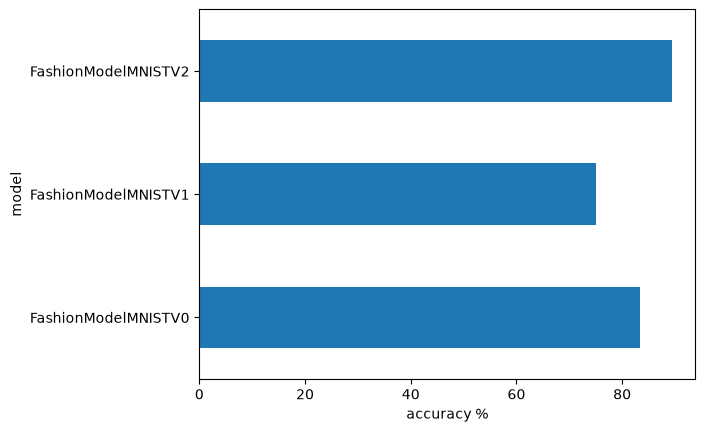

In [30]:
compare_results.set_index("model_name")["model_acc"].plot(kind= "barh")
plt.xlabel("accuracy %")
plt.ylabel("model");


In [32]:
def make_predictions(model, data, device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim= 0).to(device)

            pred_logit = model(sample).unsqeeze()

            pred_prob = torch.softmax(pred_logit, dim= 0)

            pred_probs.append(pred_prob.cpu())
    return torch.stack(pred_probs)

TypeError: only integer tensors of a single element can be converted to an index

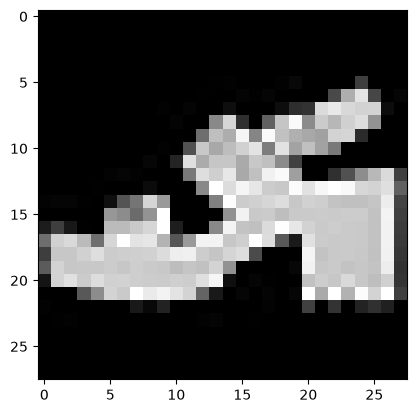

In [44]:
import random
random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k= 9):
    test_samples.append(sample)
    test_labels.append(label)

plt.imshow(test_samples[0].squeeze(), cmap= "gray")
plt.title(photos_name[test_samples[0]])